In [1]:
# imports and paramaters
import numpy as np
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import psutil

# ---- parameters ---- #
DEM_PATH      = "dem_2023_utm1m.tif"
CHANNEL_PATH  = "CLaSH26_channel2023_utm.shp"
OUTPUT_PATH   = "clash_flowgraph_2023.pkl"

CELL_SIZE = 1.0 # meters (verified: -tr 1 1)
NODATA    = -9999
CHANNEL_BUF = 1.5  # meters ~ 1m ribbon on 1m  grid (stops diagonal jumps)
BURN_DROP   = 10.0 # meters below min elevation for uniform channel mask
TREE_THRESH = 50   # min nodes for a tree to be "valid" (drainage-area cutoff)

print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

RAM: 9.8%


In [2]:
# stage DTM 0 -- retrieve metadata
with rasterio.open(DEM_PATH) as src:
    dem       = src.read(1).astype(np.float32)
    transform = src.transform
    crs       = src.crs
    file_nd   = src.nodata

if file_nd is not None:
    dem[dem == file_nd] = np.nan
dem[dem == NODATA] = np.nan

height, width = dem.shape
valid_mask = ~np.isnan(dem)
valid_count = int(valid_mask.sum())

print(f"Raster: {height} x {width}  ({height*width:,} cells)")
print(f"Valid : {valid_count:,} ({100*valid_count/(height*width):.1f}%)")
print(f"Elev  : {np.nanmin(dem):.1f} - {np.nanmax(dem):.1f} m")
print(f"RAM   : {psutil.virtual_memory().percent:.1f}%")

Raster: 927 x 898  (832,446 cells)
Valid : 405,972 (48.8%)
Elev  : 2380.9 - 2544.9 m
RAM   : 9.9%


In [3]:
# build the channel mask
channel = gpd.read_file(CHANNEL_PATH)

# safety: match CRS to the DEM (should already be EPSG:32613)
if channel.crs is None:
    raise ValueError("channel has no CRS")
if channel.crs.to_epsg() != crs.to_epsg():
    print(f"reprojecting channel {channel.crs.to_epsg()} to {crs.to_espg()}")
    channel = channel.to_crs(crs)
else:
    print("channel and dem crs matches")

# buffer channel line into a polygon ribbon (~3 m across)
channel_buf = channel.buffer(CHANNEL_BUF)

# rasterize ribbon onto DEM grid --> boolean channel mask
channel_mask = rasterize(
    [(geom, 1) for geom in channel_buf.geometry],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype=np.uint8,
).astype(bool)

print("rasterized buffered channel")

# only count channel cells that also have valid data
channel_mask &= valid_mask

print(f"channel cells: {channel_mask.sum():,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

channel and dem crs matches
rasterized buffered channel
channel cells: 3,142
RAM: 9.9%


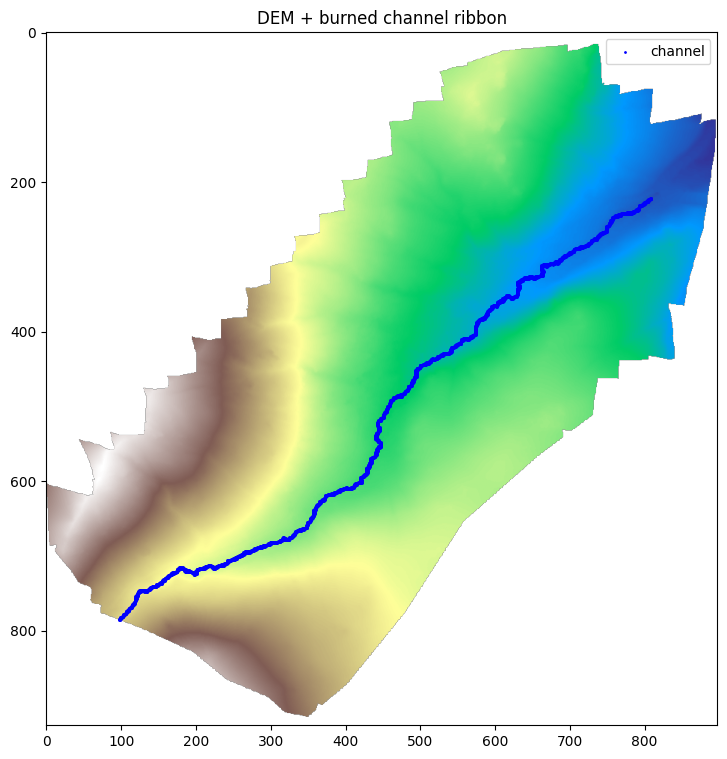

In [4]:
# quick visual: terrain + channel ribbon
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(dem, cmap='terrain')
cr, cc = np.where(channel_mask)
ax.scatter(cc, cr, s=1, c='blue', label='channel')
ax.set_title('DEM + burned channel ribbon'); ax.legend(); plt.show()

In [5]:
# burn the channel low
burn_value = float(np.nanmin(dem) - BURN_DROP)

dem_burned = dem.copy()
dem_burned[channel_mask] = burn_value

print(f"burn value: {burn_value:.1f} m  (min terrain {np.nanmin(dem):.1f} - {BURN_DROP})")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

burn value: 2370.9 m  (min terrain 2380.9 - 10.0)
RAM: 10.1%


In [6]:
# build the flow graph
G = nx.DiGraph()
neighbors = [(-1,0),(1,0),(0,1),(0,-1),(-1,-1),(-1,1),(1,-1),(1,1)]

rows, cols = np.where(valid_mask)
valid_set = set(zip(rows.tolist(), cols.tolist())) # fast neighbor membership

channel_pit_list = []
pit_list         = []
source_list      = []

for i, (r,c) in enumerate(zip(rows, cols)):
    if i % 100000 == 0:
        print(f"  node {i:,}/{valid_count:,}  RAM {psutil.virtual_memory().percent:.1f}%")
    r = int(r); c = int(c)
    cur_id    = r * width + c
    cur_elev  = dem_burned[r,c]

    G.add_node(cur_id, dem_idx=[r,c], elev=float(cur_elev),
                is_pit=False, is_channel_pit=False, is_source=False)

    min_slope = 0.0
    max_slope = 0.0
    next_id   = cur_id
    for dr, dc in neighbors:
        nr, nc = r + dr, c + dc
        if (nr, nc) in valid_set:
            s = (dem_burned[nr, nc] - cur_elev) / (np.hypot(dr, dc) * CELL_SIZE)
            if s < min_slope:
                min_slope = s; next_id = nr * width + nc
            elif s > max_slope:
                max_slope = s

    # after calculating neighboring slopes for given node:
    if min_slope < 0:
    # if you have an outpath (steepest)
        G.add_edge(cur_id, next_id, weight=float(abs(min_slope)))
        if max_slope == 0.0:
        # if you have no inflow
            G.nodes[cur_id]["is_source"] = True
            source_list.append(cur_id)
    else:
    # if no outflow (i.e. you are a pit node)
        G.nodes[cur_id]["is_pit"] = True
        pit_list.append(cur_id)
        if channel_mask[r,c]:
        # and if you are a channel node
            G.nodes[cur_id]["is_channel_pit"] = True
            channel_pit_list.append(cur_id)

            
print(f"\n  nodes: {G.number_of_nodes():,}")
print(f"  edges: {G.number_of_edges():,}")
print(f"  channel pits: {len(channel_pit_list):,}")
print(f"  generic pits: {len(pit_list):,}")
print(f"  sources: {len(source_list):,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")   

  node 0/405,972  RAM 10.6%
  node 100,000/405,972  RAM 11.3%
  node 200,000/405,972  RAM 12.2%
  node 300,000/405,972  RAM 12.9%
  node 400,000/405,972  RAM 13.9%

  nodes: 405,972
  edges: 402,544
  channel pits: 3,142
  generic pits: 3,428
  sources: 249
RAM: 14.0%


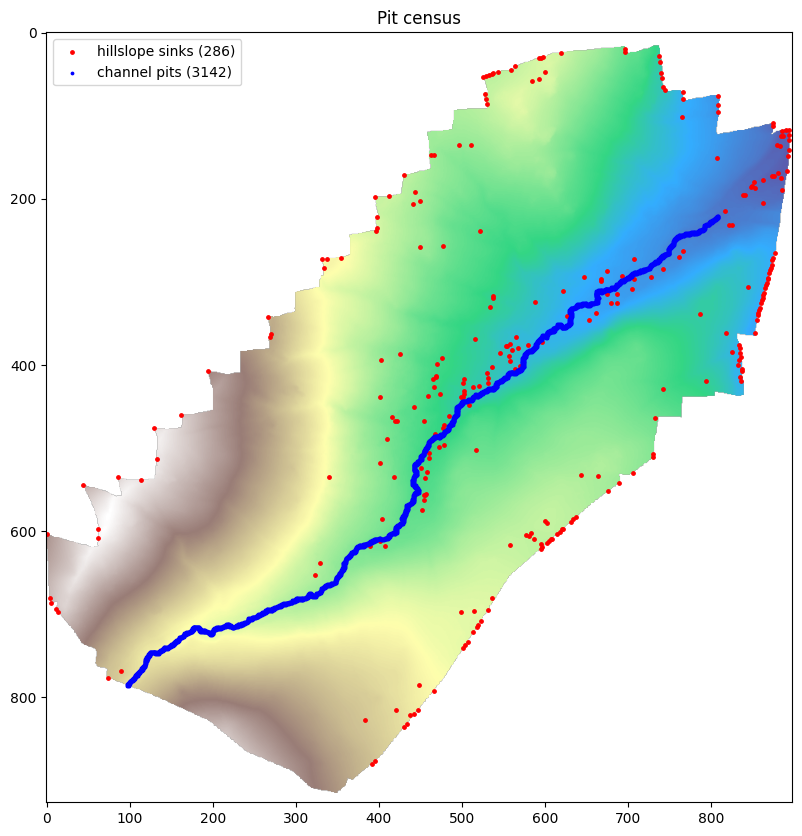

hillslope sinks (non-channel): 286 (0.070% of nodes)
channel pits: 3,142


In [7]:
# pit census -- plot channel and non- pits

channel_pit_set = set(channel_pit_list)
generic_only = [p for p in pit_list if p not in channel_pit_set]

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(dem, cmap='terrain', alpha=0.8)

def rc(ids):
    rr = [G.nodes[n]['dem_idx'][0] for n in ids]
    cc = [G.nodes[n]['dem_idx'][1] for n in ids]
    return cc, rr

if generic_only:
    x, y = rc(generic_only);     ax.scatter(x, y, s=6, c='red',  label=f'hillslope sinks ({len(generic_only)})')
if channel_pit_list:
    x, y = rc(channel_pit_list); ax.scatter(x, y, s=3, c='blue', label=f'channel pits ({len(channel_pit_list)})')
ax.set_title('Pit census'); ax.legend(); plt.savefig('CLaSH26_pitcensus2023.png'); plt.show()

n_nodes = G.number_of_nodes()
print(f"hillslope sinks (non-channel): {len(generic_only):,} ({100*len(generic_only)/n_nodes:.3f}% of nodes)")
print(f"channel pits: {len(channel_pit_list):,}")

In [8]:
# distribution of non-channel pit distances from channel
from scipy.ndimage import distance_transform_edt

# distance (in cells = meters) from every cell to the nearest channel cell
dist_to_channel = distance_transform_edt(~channel_mask)

# distance for each non-channel pit node
sink_dists = np.array([dist_to_channel[G.nodes[p]['dem_idx'][0],
                                       G.nodes[p]['dem_idx'][1]]
                       for p in generic_only])

print(f"non-channel sinks: {len(sink_dists)}")
print(f"  min {sink_dists.min():.1f} m | median {np.median(sink_dists):.1f} m | max {sink_dists.max():.1f} m")
for D in (5, 10, 15, 20, 30, 40, 50, 60, 70):
    print(f"  within {D:>3} m of channel: {(sink_dists <= D).sum():>3}")

non-channel sinks: 286
  min 2.0 m | median 121.5 m | max 291.7 m
  within   5 m of channel:  14
  within  10 m of channel:  34
  within  15 m of channel:  48
  within  20 m of channel:  63
  within  30 m of channel:  76
  within  40 m of channel:  80
  within  50 m of channel:  90
  within  60 m of channel:  99
  within  70 m of channel: 102


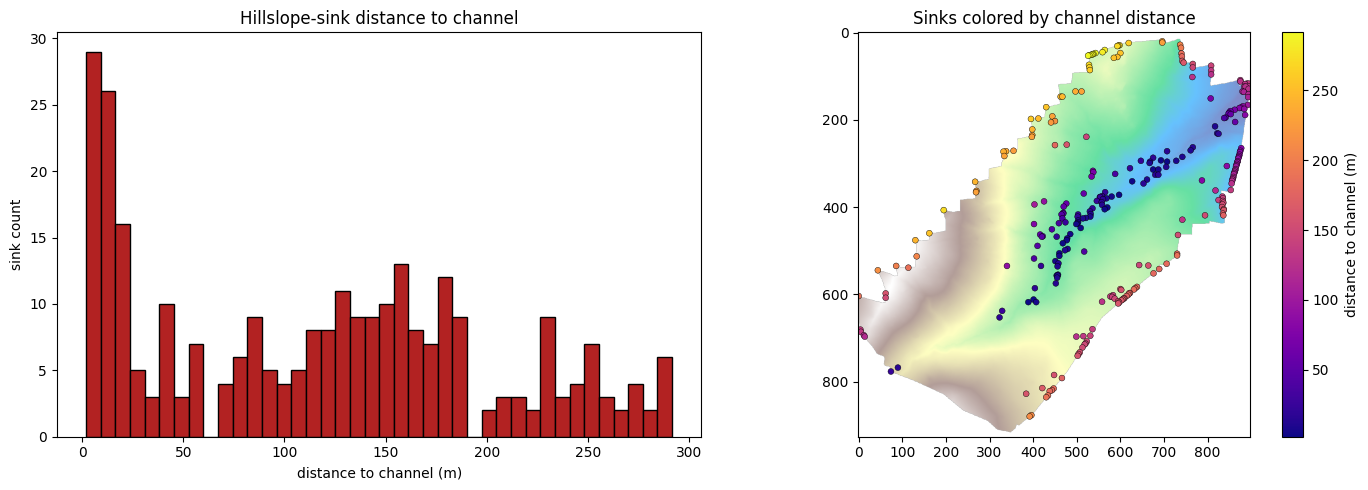

In [9]:
# plot generic-only pit node distribution

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(sink_dists, bins=40, color='firebrick', edgecolor='k')
ax[0].set_xlabel('distance to channel (m)'); ax[0].set_ylabel('sink count')
ax[0].set_title('Hillslope-sink distance to channel')

# spatial view colored by distance, to see which are the near-channel band
sr = [G.nodes[p]['dem_idx'][0] for p in generic_only]
sc = [G.nodes[p]['dem_idx'][1] for p in generic_only]
ax[1].imshow(dem, cmap='terrain', alpha=0.6)
sctr = ax[1].scatter(sc, sr, c=sink_dists, cmap='plasma', s=18, edgecolor='k', linewidth=0.3)
plt.colorbar(sctr, ax=ax[1], label='distance to channel (m)')
ax[1].set_title('Sinks colored by channel distance')
plt.tight_layout(); plt.show()

In [10]:
# =====================================================================
# AREA-BASED BREACH (replaces the distance-based breach cell)
#
# Rule: breach a non-channel sink IFF
#   (a) its orphaned upslope tree has > BREACH_AREA nodes, AND
#   (b) that tree does NOT touch the domain boundary
# Breach target = lowest non-predecessor neighbor (burn gradient pulls
# it channelward). One pass: measure on the clean graph, apply all,
# then re-trace.
# =====================================================================

BREACH_AREA = TREE_THRESH   # reuse the "meaningful tree" cutoff (50)

neighbors = [(-1,0),(1,0),(0,1),(0,-1),(-1,-1),(-1,1),(1,-1),(1,1)]

# --- precompute a boundary mask: valid cell with any invalid/off-grid neighbor
print("computing boundary mask...")
boundary_mask = np.zeros((height, width), dtype=bool)
vr, vc = np.where(valid_mask)
for r, c in zip(vr, vc):
    for dr, dc in neighbors:
        nr, nc = r + dr, c + dc
        if not (0 <= nr < height and 0 <= nc < width) or not valid_mask[nr, nc]:
            boundary_mask[r, c] = True
            break
print(f"  boundary cells: {boundary_mask.sum():,}")

# --- helper: trace orphaned tree of a sink, flag if it touches boundary
def sink_tree_and_boundary(graph, sink, cap=300000):
    visited = set()
    stack = [sink]
    touches = False
    while stack and len(visited) < cap:
        cur = stack.pop()
        if cur in visited:
            continue
        visited.add(cur)
        r, c = graph.nodes[cur]['dem_idx']
        if boundary_mask[r, c]:
            touches = True
        stack.extend(graph.predecessors(cur))
    return visited, touches

# --- evaluate every non-channel sink on the CLEAN graph
channel_pit_set = set(channel_pit_list)
sinks = [p for p in pit_list if p not in channel_pit_set]
print(f"evaluating {len(sinks)} non-channel sinks...")

to_breach = []
skip_small = 0
skip_boundary = 0
for s in sinks:
    tree_nodes, touches = sink_tree_and_boundary(G, s)
    if len(tree_nodes) <= BREACH_AREA:
        skip_small += 1
        continue
    if touches:
        skip_boundary += 1
        continue
    to_breach.append(s)

print(f"  breach candidates (>{BREACH_AREA} nodes, interior): {len(to_breach)}")
print(f"  skipped (too small): {skip_small}")
print(f"  skipped (touches boundary): {skip_boundary}")

# --- apply breaches: connect each to lowest non-predecessor neighbor
breached = 0
no_target = 0
for pid in to_breach:
    r, c = G.nodes[pid]['dem_idx']
    cur_elev = dem_burned[r, c]
    preds = set(G.predecessors(pid))
    best_elev = np.inf; best_id = None; best_slope = None
    for dr, dc in neighbors:
        nr, nc = r + dr, c + dc
        if (nr, nc) in valid_set:
            nid = nr * width + nc
            if nid in preds:
                continue
            ne = dem_burned[nr, nc]
            if ne < best_elev:
                best_elev = ne; best_id = nid
                best_slope = (ne - cur_elev) / (np.hypot(dr, dc) * CELL_SIZE)
    if best_id is None:
        no_target += 1
        continue
    G.add_edge(pid, best_id, weight=float(abs(best_slope)))
    G.nodes[pid]['is_pit'] = False
    breached += 1

# --- refresh bookkeeping
pit_list = [p for p in pit_list if G.out_degree(p) == 0]
generic_only = [p for p in pit_list if p not in channel_pit_set]

print(f"\n  breached: {breached}")
print(f"  no valid target: {no_target}")
print(f"  remaining non-channel sinks: {len(generic_only)}")
print(f"  edges now: {G.number_of_edges():,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

computing boundary mask...
  boundary cells: 3,958
evaluating 286 non-channel sinks...
  breach candidates (>50 nodes, interior): 88
  skipped (too small): 98
  skipped (touches boundary): 100

  breached: 78
  no valid target: 10
  remaining non-channel sinks: 208
  edges now: 402,622
RAM: 14.2%


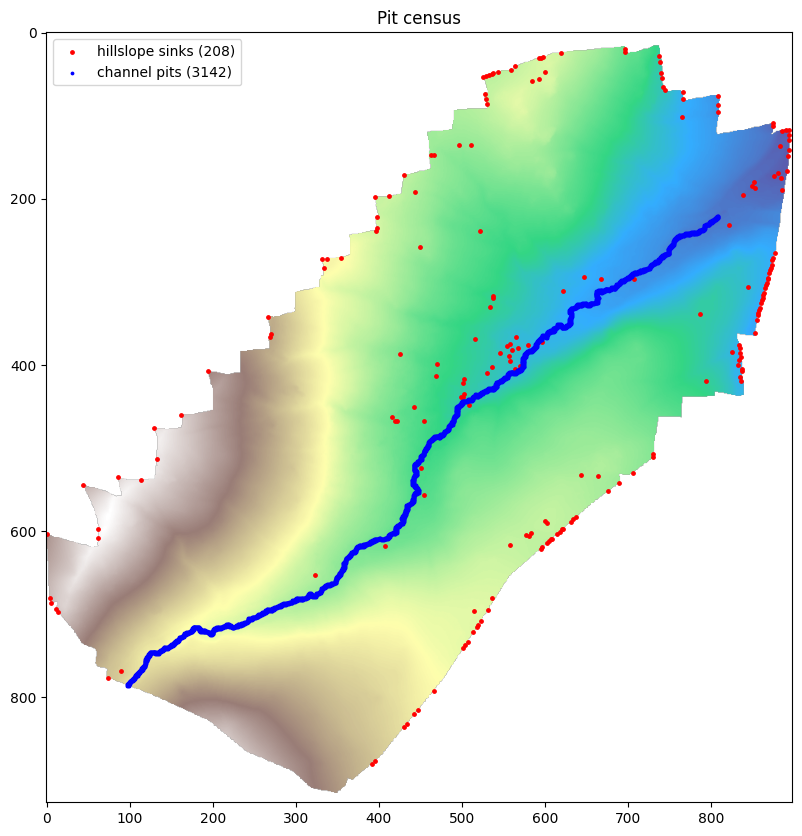

hillslope sinks (non-channel): 208 (0.051% of nodes)
channel pits: 3,142


In [11]:
# pit census pt.2 -- plot after breeching

channel_pit_set = set(channel_pit_list)
generic_only = [p for p in pit_list if p not in channel_pit_set]

fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(dem, cmap='terrain', alpha=0.8)

def rc(ids):
    rr = [G.nodes[n]['dem_idx'][0] for n in ids]
    cc = [G.nodes[n]['dem_idx'][1] for n in ids]
    return cc, rr

if generic_only:
    x, y = rc(generic_only);     ax.scatter(x, y, s=6, c='red',  label=f'hillslope sinks ({len(generic_only)})')
if channel_pit_list:
    x, y = rc(channel_pit_list); ax.scatter(x, y, s=3, c='blue', label=f'channel pits ({len(channel_pit_list)})')
ax.set_title('Pit census'); ax.legend(); plt.savefig('CLaSH26_pitcensus2023.png'); plt.show()

n_nodes = G.number_of_nodes()
print(f"hillslope sinks (non-channel): {len(generic_only):,} ({100*len(generic_only)/n_nodes:.3f}% of nodes)")
print(f"channel pits: {len(channel_pit_list):,}")

In [12]:
# tree trace function
def trace_tree_from_pit(graph, pit_node, max_depth=200000):
    """All upstream nodes flowing into pit_node (walks predecessors)."""
    visited = set()
    to_visit = [pit_node]
    while to_visit and len(visited) < max_depth:
        cur = to_visit.pop()
        if cur in visited:
            continue
        visited.add(cur)
        to_visit.extend(graph.predecessors(cur))
    return graph.subgraph(visited).copy()

In [13]:
# trace trees
kept_trees = {}
for pid in channel_pit_list:
    tree = trace_tree_from_pit(G, pid)
    if tree.number_of_nodes() > TREE_THRESH:
        kept_trees[pid] = tree

sizes = sorted((t.number_of_nodes() for t in kept_trees.values()), reverse=True)
print(f"channel pits: {len(channel_pit_list):,}")
print(f"kept trees (> {TREE_THRESH} nodes): {len(kept_trees):,}")
if sizes:
    print(f"tree sizes: max {sizes[0]:,}, median {sizes[len(sizes)//2]:,}, min {sizes[-1]:,}")
    print(f"total nodes in kept trees: {sum(sizes):,}")
print(f"RAM: {psutil.virtual_memory().percent:.1f}%")

channel pits: 3,142
kept trees (> 50 nodes): 325
tree sizes: max 35,424, median 212, min 51
total nodes in kept trees: 235,446
RAM: 15.6%


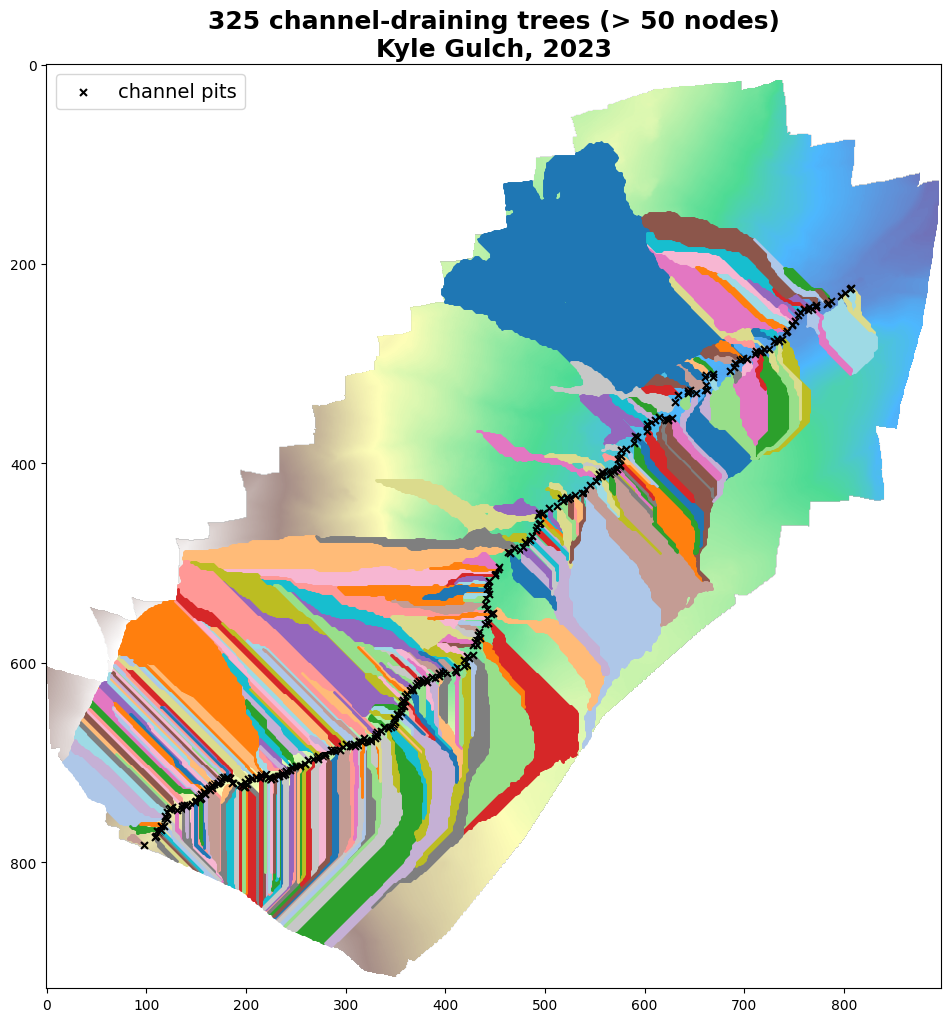

In [14]:
# draw trees on the terrain
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(dem, cmap='terrain', alpha=0.7)

cmap = plt.cm.tab20
for k, (pid, tree) in enumerate(sorted(kept_trees.items(),
                                       key=lambda kv: -kv[1].number_of_nodes())):
    rr = [G.nodes[n]['dem_idx'][0] for n in tree.nodes()]
    cc = [G.nodes[n]['dem_idx'][1] for n in tree.nodes()]
    ax.scatter(cc, rr, s=1, color=cmap(k % 20))
    pr, pc = G.nodes[pid]['dem_idx']
    ax.scatter([pc], [pr], s=25, c='black', marker='x', label=f'channel pits')

# 2. Get all legend handles and labels from the current axes
handles, labels = plt.gca().get_legend_handles_labels()



ax.set_title(f'{len(kept_trees)} channel-draining trees (> {TREE_THRESH} nodes)\n'
             f'Kyle Gulch, 2023',fontsize=18, fontweight='bold')
# 3. Pass only the first item of each list to the legend
plt.legend([handles[0]], [labels[0]], loc='upper left',fontsize=14)
#plt.savefig('CLaSH26_channeltrees_2023sfm_areabreach.png')
plt.show()